# Arabic Intent Classification — Egyptian Call-Centre Transcripts
### Track A: Fine-tuning an Arabic Encoder (AraBERT)

Classifies a single customer utterance (Egyptian Arabic, transcribed speech)
into one of **27 fixed intents** for a telecom support call centre.

**Approach:** Track A — fine-tune `aubmindlab/bert-base-arabertv02-twitter`

## 1. Environment Setup

In [ ]:
!nvidia-smi || echo "No GPU detected -- training will fall back to CPU (still fine for this dataset size)."


Sun Aug 30 21:45:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q transformers datasets evaluate accelerate arabert scikit-learn pandas matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 9.9 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import json
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

from arabert.preprocess import ArabertPreprocessor

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Transformers/torch ready. PyTorch:", torch.__version__)


Device: cuda
Transformers/torch ready. PyTorch: 2.11.0+cu128


In [ ]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False


## 3. The 27 Intents



In [ ]:
INTENTS = [
    "activate_line",
    "add_data_package",
    "add_family_line",
    "app_navigation_assistance",
    "ask_price",
    "bill_inquiry",
    "booking_reservation",
    "cancel_addon",
    "change_credit_limit",
    "confirm_agree",
    "convert_to_postpaid",
    "decline_reject",
    "downgrade_package",
    "greeting",
    "identify_self",
    "inquiry_installment",
    "package_renewal_inquiry",
    "points_redemption",
    "provide_number",
    "request_agent_action",
    "request_info",
    "roaming_package",
    "system_issue_complaint",
    "thank_close",
    "transfer_data_between_lines",
    "transfer_ownership",
    "update_account_info",
]
assert len(INTENTS) == 27
print(f"{len(INTENTS)} intents loaded.")


27 intents loaded.


## 4. Load the Dataset

In [ ]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

# ONE data file -- the split happens here in code, not as separate files,
# so it's always reproducible from the same source with the same seed.
full_df = load_jsonl("dataset.jsonl")

# 70% train / 15% val / 15% test, stratified so every intent is
# represented proportionally in all three splits.
train_df, temp_df = train_test_split(
    full_df, test_size=0.30, random_state=SEED, stratify=full_df["intent"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["intent"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# NOTE: on Colab, upload dataset.jsonl via the file pane (or mount Drive)
# so it lands at /content/dataset.jsonl, then point load_jsonl there --
# or just keep the relative path if you cd into the same folder.

print("Full dataset:", len(full_df))
print("Train rows:", len(train_df))
print("Val rows:  ", len(val_df), "(used during training / iteration)")
print("Test rows: ", len(test_df), "(held out, scored once at the very end)")
train_df.head()


Full dataset: 598
Train rows: 418
Val rows:   90 (used during training / iteration)
Test rows:  90 (held out, scored once at the very end)


,agent_text,customer_text,intent
0,,محتاج ازود حد الاستخدام مؤقتا عشان مناسبه معينه,change_credit_limit
1,قوليلي رقم الموبايل بتاع حضرتك,صفر واحد اتنين تلاته اربعه خمسه سته سبعه,provide_number
2,,الباقه بتتجدد امتى بالظبط,package_renewal_inquiry
3,,لا خالص مش موافق على كده,decline_reject
4,,عايز اعرف اقرب تاريخ لانتهاء النقاط بتاعتي,points_redemption


## 5. Sanity Checks

In [ ]:
# All labels must be inside the fixed 27-intent set
unknown_train = set(train_df["intent"]) - set(INTENTS)
unknown_val = set(val_df["intent"]) - set(INTENTS)
assert not unknown_train, f"Unknown train labels: {unknown_train}"
assert not unknown_val, f"Unknown val labels: {unknown_val}"

# Every intent should appear in both splits
missing_in_train = set(INTENTS) - set(train_df["intent"])
missing_in_val = set(INTENTS) - set(val_df["intent"])
print("Intents missing from train:", missing_in_train or "none")
print("Intents missing from val:  ", missing_in_val or "none")

# Duplicate / leaking rows between train and val
dupes_within_train = train_df["customer_text"].duplicated().sum()
overlap = set(train_df["customer_text"]) & set(val_df["customer_text"])
print("Duplicate rows inside train:", dupes_within_train)
print("customer_text overlapping between train/val:", len(overlap))


Intents missing from train: none
Intents missing from val:   none
Duplicate rows inside train: 0
customer_text overlapping between train/val: 0


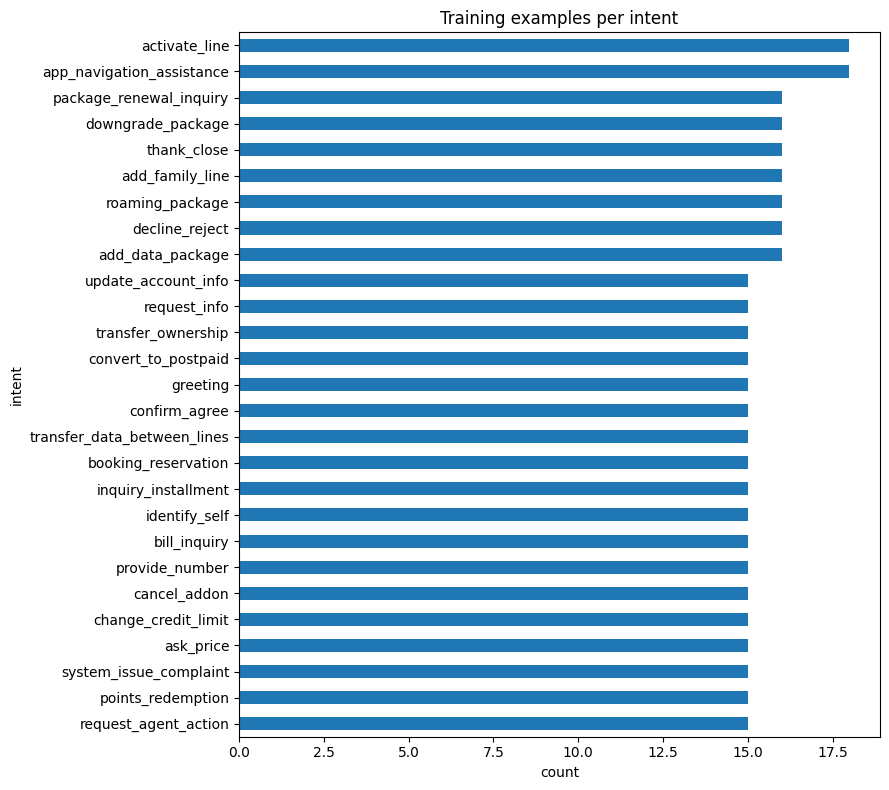

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))
train_df["intent"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Training examples per intent")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()


## 6. AraBERT Preprocessing

The official AraBERT preprocessor normalises Arabic text

In [ ]:
MODEL_NAME = "aubmindlab/bert-base-arabertv02-twitter"

arabert_prep = ArabertPreprocessor(model_name=MODEL_NAME)

CONTEXT_DEPENDENT_INTENTS = {"identify_self", "provide_number", "confirm_agree", "decline_reject"}

def build_text(row):
    customer = row["customer_text"]
    agent = row.get("agent_text", "") or ""
    if row["intent"] in CONTEXT_DEPENDENT_INTENTS and agent:
        raw = f"{agent} [SEP] {customer}"
    else:
        raw = customer
    return arabert_prep.preprocess(raw)

for df in (train_df, val_df):
    df["text"] = df.apply(build_text, axis=1)

train_df[["customer_text", "text", "intent"]].sample(5, random_state=1)


,customer_text,text,intent
358,عايز الغي كل الاشتراكات الاضافيه اللي على رقمي,عايز الغي كل الاشتراكات الاضافيه اللي على رقمي,cancel_addon
164,الرقم القومي هو ثلاثه واحد اتنين تلاته اربعه خ...,قوليلي الرقم القومي عشان نتاكد [SEP] الرقم الق...,provide_number
17,منى سعيد ابراهيم,اسم حضرتك ايه بالظبط [SEP] منى سعيد ابراهيم,identify_self
67,مش عارفه افتح صفحه الاشعارات من التطبيق,مش عارفه افتح صفحه الاشعارات من التطبيق,app_navigation_assistance
4,عايز اعرف اقرب تاريخ لانتهاء النقاط بتاعتي,عايز اعرف اقرب تاريخ لانتهاء النقاط بتاعتي,points_redemption


## 7. Label Encoding

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(INTENTS)

train_df["label"] = label_encoder.transform(train_df["intent"])
val_df["label"] = label_encoder.transform(val_df["intent"])

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

print("Num labels:", len(id2label))


Num labels: 27


## 8. Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 64  # utterances are short; keeps padding/latency down

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)

train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)

train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset = val_dataset.map(tokenize_batch, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")

print(train_dataset)


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/751k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/418 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 418
})


## 9. Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(INTENTS),
    id2label=id2label,
    label2id=label2id,
)
model.to(DEVICE)
print("Model loaded:", MODEL_NAME, "-> num_labels =", model.config.num_labels)


model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: aubmindlab/bert-base-arabertv02-twitter -> num_labels = 27


## 10. Metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "precision_macro": precision,
        "recall_macro": recall,
    }


## 11. Training

In [ ]:
training_args = TrainingArguments(
    output_dir="./intent_model",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to=[],
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(train_result)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,3.238054,3.030110,0.288889,0.270076,0.350750,0.283951
2,2.840737,2.666565,0.555556,0.506395,0.569048,0.555556
3,2.453916,2.332417,0.711111,0.688103,0.777116,0.716049
4,2.084173,2.027832,0.744444,0.714499,0.762654,0.753086
5,1.783045,1.774467,0.844444,0.840300,0.888889,0.851852
6,1.559929,1.625606,0.855556,0.848677,0.892593,0.861111
7,1.401714,1.516228,0.855556,0.848677,0.892593,0.861111
8,1.347622,1.493808,0.855556,0.848677,0.892593,0.861111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=216, training_loss=2.088648866724085, metrics={'train_runtime': 441.3057, 'train_samples_per_second': 7.578, 'train_steps_per_second': 0.489, 'total_flos': 110005107886080.0, 'train_loss': 2.088648866724085, 'epoch': 8.0})


## 12. Evaluation

In [ ]:
eval_metrics = trainer.evaluate()
print("Validation metrics:")
for k, v in eval_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
1.347622,1.625606,8,0.855556,0.848677,0.892593,0.861111


Validation metrics:
  eval_loss: 1.6256
  eval_accuracy: 0.8556
  eval_f1_macro: 0.8487
  eval_precision_macro: 0.8926
  eval_recall_macro: 0.8611


In [ ]:
predictions = trainer.predict(val_dataset)
pred_ids = np.argmax(predictions.predictions, axis=-1)
true_ids = predictions.label_ids

pred_labels = label_encoder.inverse_transform(pred_ids)
true_labels = label_encoder.inverse_transform(true_ids)

macro_f1 = f1_score(true_labels, pred_labels, average="macro")
accuracy = accuracy_score(true_labels, pred_labels)

print(f"Macro F1:  {macro_f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print()
print(classification_report(true_labels, pred_labels, labels=INTENTS, digits=3, zero_division=0))


Macro F1:  0.8487
Accuracy:  0.8556

                             precision    recall  f1-score   support

              activate_line      1.000     1.000     1.000         4
           add_data_package      1.000     1.000     1.000         4
            add_family_line      1.000     1.000     1.000         3
  app_navigation_assistance      0.750     1.000     0.857         3
                  ask_price      1.000     0.250     0.400         4
               bill_inquiry      0.600     1.000     0.750         3
        booking_reservation      1.000     1.000     1.000         4
               cancel_addon      0.500     0.667     0.571         3
        change_credit_limit      1.000     0.667     0.800         3
              confirm_agree      1.000     0.250     0.400         4
        convert_to_postpaid      0.750     1.000     0.857         3
             decline_reject      0.400     0.667     0.500         3
          downgrade_package      1.000     1.000     1.000       

### Confusion matrix

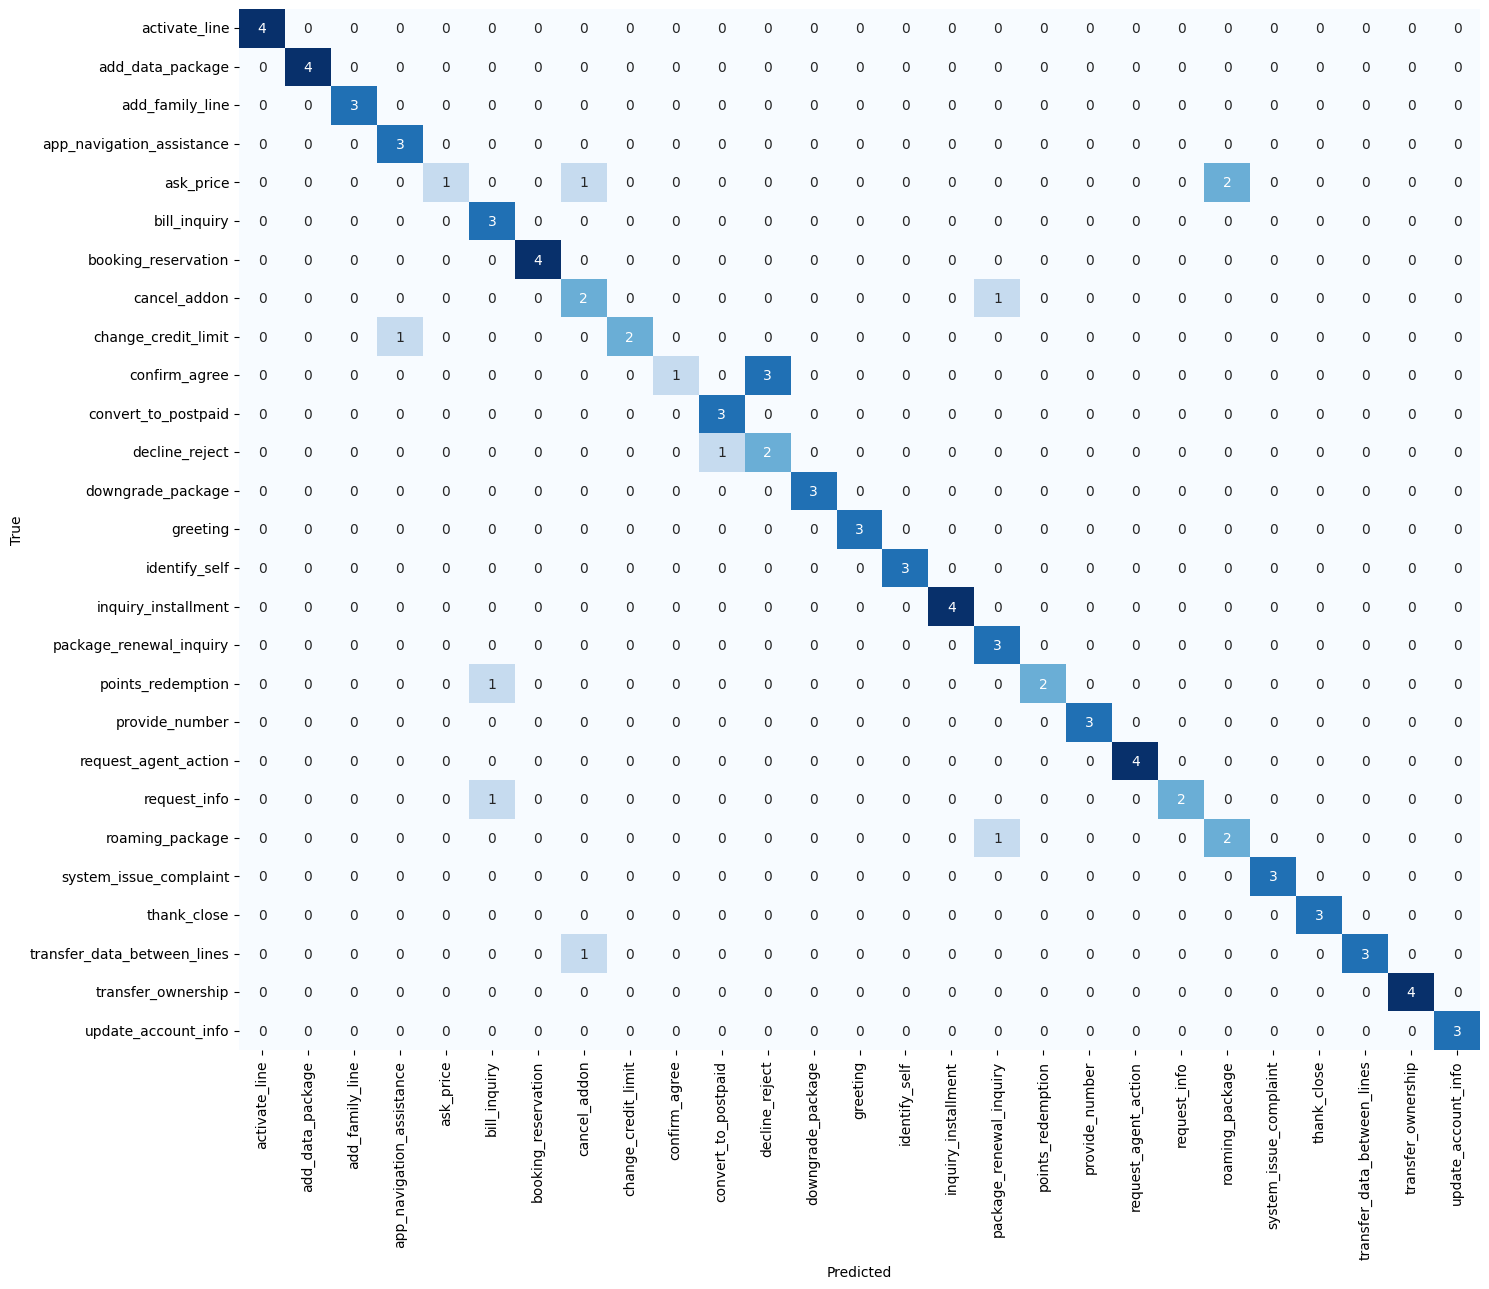

In [ ]:
cm = confusion_matrix(true_labels, pred_labels, labels=INTENTS)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=INTENTS, yticklabels=INTENTS,
            cmap="Blues", ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Confusion analysis — three worst intents


In [ ]:
report_dict = classification_report(
    true_labels, pred_labels, labels=INTENTS, output_dict=True, zero_division=0
)
per_intent_f1 = pd.Series({intent: report_dict[intent]["f1-score"] for intent in INTENTS})
worst_three = per_intent_f1.sort_values().head(3)
print("Three worst intents by F1:")
print(worst_three)

val_df_reset = val_df.reset_index(drop=True)
print("\n========== ERRORS FOR THE THREE WORST INTENTS ==========")
for intent in worst_three.index:
    print(f"\n--- {intent} (F1={worst_three[intent]:.3f}) ---")
    mask = (true_labels == intent) & (pred_labels != intent)
    errs = val_df_reset.loc[mask, ["customer_text"]].copy()
    errs["predicted_as"] = pred_labels[mask]
    if errs.empty:
        print("  (no true-label errors for this intent on the val set)")
    else:
        for _, row in errs.iterrows():
            print(f"  '{row['customer_text']}'  ->  predicted: {row['predicted_as']}")


Three worst intents by F1:
ask_price         0.4
confirm_agree     0.4
decline_reject    0.5
dtype: float64

========== ERRORS FOR THE THREE WORST INTENTS ==========

--- ask_price (F1=0.400) ---
  'عايز اعرف سعر تفعيل خدمه الرومينج قبل السفر'  ->  predicted: roaming_package
  'الرومينج في السعوديه بيتحسب بكام في الدقيقه'  ->  predicted: roaming_package
  'الاشتراك في خدمه النغمه ده بكام في الشهر'  ->  predicted: cancel_addon

--- confirm_agree (F1=0.400) ---
  'نبعتلك الفاتوره بالايميل بدل الرساله'  ->  predicted: decline_reject
  'تمام موافق'  ->  predicted: decline_reject
  'ماشي موافق خالص'  ->  predicted: decline_reject

--- decline_reject (F1=0.500) ---
  'لأ مش عايز التحويل ده'  ->  predicted: convert_to_postpaid


## 13. Output Constraint


In [ ]:
def predict_intent(text, agent_text=""):
    """ Predict a single intent ID, guaranteed to be one of the 27 fixed labels."""
    raw = f"{agent_text} [SEP] {text}" if agent_text else text
    clean = arabert_prep.preprocess(raw)
    enc = tokenizer(clean, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
    pred_id = int(torch.argmax(logits, dim=-1))
    return id2label[pred_id]

# sample checks against the task brief's worked examples
samples = [
    ("عايز اعرف الباقه بتتجدد امتي", "package_renewal_inquiry"),
    ("النت بطيء جدا من امبارح", "system_issue_complaint"),
    ("متشكر يا فندم مع السلامة", "thank_close"),
    ("عايز انقل ملكية الخط لاخويا", "transfer_ownership"),
]
for text, expected in samples:
    pred = predict_intent(text)
    mark = "OK" if pred == expected else "MISMATCH"
    print(f"[{mark}] '{text}' -> predicted={pred} (expected={expected})")


[OK] 'عايز اعرف الباقه بتتجدد امتي' -> predicted=package_renewal_inquiry (expected=package_renewal_inquiry)
[OK] 'النت بطيء جدا من امبارح' -> predicted=system_issue_complaint (expected=system_issue_complaint)
[OK] 'متشكر يا فندم مع السلامة' -> predicted=thank_close (expected=thank_close)
[OK] 'عايز انقل ملكية الخط لاخويا' -> predicted=transfer_ownership (expected=transfer_ownership)


## 14. Latency Benchmark

In [ ]:
def benchmark_latency(device_name, n_runs=100):
    bench_model = model.to(device_name)
    bench_model.eval()

    bench_text = arabert_prep.preprocess(val_df.iloc[0]["customer_text"])
    enc = tokenizer(bench_text, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
    enc = {k: v.to(device_name) for k, v in enc.items()}

    # warm-up
    with torch.no_grad():
        for _ in range(20):
            _ = bench_model(**enc)

    timings = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = bench_model(**enc)
            if device_name == "cuda":
                torch.cuda.synchronize()
            timings.append((time.perf_counter() - start) * 1000)  # ms

    timings = np.array(timings)
    print(f"Hardware: {device_name.upper()}")
    print(f"Batch size: 1, warm-up runs: 20, timed runs: {n_runs}")
    print(f"Median latency: {np.median(timings):.2f} ms")
    print(f"p95 latency:    {np.percentile(timings, 95):.2f} ms")
    print(f"Mean latency:   {timings.mean():.2f} ms")
    print()
    return timings

LATENCY_DEVICE = "cpu"
timings = benchmark_latency(LATENCY_DEVICE)

if torch.cuda.is_available():
    timings_gpu = benchmark_latency("cuda")

model.to(DEVICE)

Hardware: CPU
Batch size: 1, warm-up runs: 20, timed runs: 100
Median latency: 178.95 ms
p95 latency:    276.90 ms
Mean latency:   203.11 ms

Hardware: CUDA
Batch size: 1, warm-up runs: 20, timed runs: 100
Median latency: 9.20 ms
p95 latency:    12.57 ms
Mean latency:   9.83 ms



BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(64000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 15. Held-Out Test Evaluation

In [ ]:
test_df["text"] = test_df.apply(build_text, axis=1)
test_df["label"] = label_encoder.transform(test_df["intent"])

test_dataset = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)
test_dataset = test_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.remove_columns(["text"])
test_dataset.set_format(type="torch")

test_predictions = trainer.predict(test_dataset)
test_pred_ids = np.argmax(test_predictions.predictions, axis=-1)
test_true_ids = test_predictions.label_ids

test_pred_labels = label_encoder.inverse_transform(test_pred_ids)
test_true_labels = label_encoder.inverse_transform(test_true_ids)

test_macro_f1 = f1_score(test_true_labels, test_pred_labels, average="macro")
test_accuracy = accuracy_score(test_true_labels, test_pred_labels)

print("=== HELD-OUT TEST RESULTS (scored once) ===")
print(f"Macro F1:  {test_macro_f1:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print()
print(classification_report(test_true_labels, test_pred_labels, labels=INTENTS, digits=3, zero_division=0))


Map:   0%|          | 0/90 [00:00<?, ? examples/s]

=== HELD-OUT TEST RESULTS (scored once) ===
Macro F1:  0.7495
Accuracy:  0.7667

                             precision    recall  f1-score   support

              activate_line      0.667     0.667     0.667         3
           add_data_package      0.500     1.000     0.667         3
            add_family_line      0.500     0.333     0.400         3
  app_navigation_assistance      0.500     0.750     0.600         4
                  ask_price      0.000     0.000     0.000         3
               bill_inquiry      0.750     0.750     0.750         4
        booking_reservation      1.000     1.000     1.000         3
               cancel_addon      1.000     1.000     1.000         4
        change_credit_limit      1.000     1.000     1.000         4
              confirm_agree      1.000     0.333     0.500         3
        convert_to_postpaid      0.600     0.750     0.667         4
             decline_reject      0.500     0.667     0.571         3
          downgrade_p

## 16. Inference on the Blind Test Set

Point `BLIND_TEST_PATH` at the 150-utterance file provided on day 4
(one JSON object per line, at least a `customer_text` field and
optionally `agent_text`). Produces `predictions.txt`, one label per
line, in the same order as the input.

In [ ]:
BLIND_TEST_PATH = "blind_test.jsonl"  # replace with the real path once supplied

import os

if os.path.exists(BLIND_TEST_PATH):
    blind_df = load_jsonl(BLIND_TEST_PATH)
    preds = [
        predict_intent(row["customer_text"], row.get("agent_text", ""))
        for _, row in blind_df.iterrows()
    ]
    with open("predictions.txt", "w", encoding="utf-8") as f:
        for p in preds:
            f.write(p + "\n")
    print(f"Wrote {len(preds)} predictions to predictions.txt")
else:
    print(f"'{BLIND_TEST_PATH}' not found yet -- this cell will run once the blind test file is provided.")

## 17. Save the Model

In [ ]:
SAVE_DIR = "./intent_model_final"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved fine-tuned model + tokenizer to", SAVE_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model + tokenizer to ./intent_model_final


In [ ]:
summary = f"""
EVALUATION SUMMARY -- Egyptian Arabic Intent Classification (Track A: AraBERT)
================================================================================
Model:              {MODEL_NAME}
Train / Val size:   {len(train_df)} / {len(val_df)}
Macro F1:            {macro_f1:.3f}
Accuracy:             {accuracy:.3f}

Three worst intents (by F1):
{chr(10).join(f"  - {intent}: {score:.3f}" for intent, score in worst_three.items())}

Latency (batch=1, CPU, median of {n_runs} runs after 20 warm-up):
  {np.median(timings):.2f} ms

Overlapping-intent rules applied (see Section 3 above):
  1. identify_self vs provide_number   -> decided by name vs bare digits
  2. app_navigation_assistance vs system_issue_complaint -> "where" vs "broken"
  3. bill_inquiry vs ask_price          -> already charged vs cost up front
  4. request_info                       -> fallback only, never the default guess
================================================================================
"""
print(summary)

with open("evaluation_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)



EVALUATION SUMMARY -- Egyptian Arabic Intent Classification (Track A: AraBERT)
Model:              aubmindlab/bert-base-arabertv02-twitter
Train / Val size:   418 / 90
Macro F1:            0.849
Accuracy:             0.856

Three worst intents (by F1):
  - ask_price: 0.400
  - confirm_agree: 0.400
  - decline_reject: 0.500

Latency (batch=1, CPU, median of 100 runs after 20 warm-up):
  178.95 ms

Overlapping-intent rules applied (see Section 3 above):
  1. identify_self vs provide_number   -> decided by name vs bare digits
  2. app_navigation_assistance vs system_issue_complaint -> "where" vs "broken"
  3. bill_inquiry vs ask_price          -> already charged vs cost up front
  4. request_info                       -> fallback only, never the default guess



### Comparison between track A and track C

In [ ]:
def fmt_row(label, val_a, val_c, width_label=26, width_col=25):
    return f"{label:<{width_label}}{val_a:<{width_col}}{val_c}"

comparison_lines = [
    "TRACK COMPARISON -- Egyptian Arabic Intent Classification",
    "=" * 80,
    fmt_row("", "Track A (AraBERT)", "Track C (Qwen2.5-7B few-shot)"),
    fmt_row("Approach", "Fine-tuned encoder", "Few-shot prompting, no training"),
    fmt_row("Training", f"~{train_result.metrics.get('train_runtime', 0)/60:.1f} min on {DEVICE.upper()}", "None"),
    "-" * 80,
    fmt_row("Val Macro F1", f"{macro_f1:.3f}", "0.934"),
    fmt_row("Val Accuracy", f"{accuracy:.3f}", "0.933"),
    "-" * 80,
    fmt_row("Test Macro F1", f"{test_macro_f1:.3f}", "0.840"),
    fmt_row("Test Accuracy", f"{test_accuracy:.3f}", "0.856"),
    fmt_row("Val -> Test drop", f"{macro_f1 - test_macro_f1:.3f}", "0.094"),
    "-" * 80,
    fmt_row("Median latency", f"{np.median(timings):.1f} ms ({LATENCY_DEVICE.upper()})", "2929.4 ms (CUDA)"),
    fmt_row("Output constraint", "Native (27-unit head)", "Prompt + validation (0.4% fallback)"),
    "=" * 80,
    "",
    "Cross-track finding: two utterances independently defeated BOTH tracks",
    "despite completely different architectures -- strong evidence these are",
    "genuinely ambiguous/hard cases in the dataset itself, not a weakness of",
    "either approach:",
    '  - "ماشي موافق خالص" (confirm_agree) -> misread as decline_reject in both',
    '  - "نبعتلك الفاتوره بالايميل بدل الرساله" -> unstable across both tracks',
    "    (Track A: predicted decline_reject; Track C: flip-flopped between",
    "    request_agent_action / bill_inquiry / update_account_info across runs).",
    "    Worth flagging as a dataset labeling-ambiguity item rather than a",
    "    model failure on either side.",
    "=" * 80,
]

comparison = "\n".join(comparison_lines)
print(comparison)

with open("track_comparison.txt", "w", encoding="utf-8") as f:
    f.write(comparison)

TRACK COMPARISON -- Egyptian Arabic Intent Classification
                          Track A (AraBERT)        Track C (Qwen2.5-7B few-shot)
Approach                  Fine-tuned encoder       Few-shot prompting, no training
Training                  ~7.4 min on CUDA         None
--------------------------------------------------------------------------------
Val Macro F1              0.849                    0.934
Val Accuracy              0.856                    0.933
--------------------------------------------------------------------------------
Test Macro F1             0.749                    0.840
Test Accuracy             0.767                    0.856
Val -> Test drop          0.099                    0.094
--------------------------------------------------------------------------------
Median latency            179.0 ms (CPU)           2929.4 ms (CUDA)
Output constraint         Native (27-unit head)    Prompt + validation (0.4% fallback)

Cross-track finding: two utterances in

In [ ]:
import shutil
import os

source = "/content/intent_model_final"
destination = "/content/drive/MyDrive/Arabic_Intent_Classification/intent_model_final"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Model saved to Google Drive successfully!")
print(destination)

Model saved to Google Drive successfully!
/content/drive/MyDrive/Arabic_Intent_Classification/intent_model_final
